# Phân cụm khách hàng — Huấn luyện mô hình (K-Means, Hierarchical, DBSCAN)

Notebook này thực hiện:
1. Tìm số cụm k tối ưu bằng phương pháp Elbow + Silhouette
2. Huấn luyện và đánh giá 3 mô hình: **K-Means**, **Hierarchical (Agglomerative)**, **DBSCAN**
3. So sánh 3 mô hình
4. Phân tích đặc điểm (business profiling) của các cụm theo mô hình tốt nhất

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
# import wandb  

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# wandb.login() 

# Đọc dữ liệu đã chuẩn hóa (dùng để huấn luyện)
processed_data_path = "../data/processed/customer_segmentation_scaled.csv"
X_df = pd.read_csv(processed_data_path)
X = X_df[['Recency', 'Frequency', 'Monetary']].values
print(f"Kích thước ma trận dữ liệu: {X.shape}")

# Đọc dữ liệu RFM thô (đơn vị gốc, dùng để diễn giải cụm sau này)
rfm_raw = pd.read_csv("../data/processed/customer_segmentation.csv")

Kích thước ma trận dữ liệu: (4338, 3)


## 1. Tìm số cụm k tối ưu — phương pháp Elbow + Silhouette

In [14]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
import wandb

k_range = range(2, 6)
results = []

print("--- Bắt đầu Grid Search K-Means và Log từng siêu tham số lên W&B ---")

for k in k_range:
    try:
        # Khởi tạo một lượt chạy mới trên W&B cho từng giá trị K
        run = wandb.init(
            project="customer-segmentation-online-retail",
            name=f"kmeans-k{k}",
            group="kmeans-tuning",  # Gom tất cả các lượt chạy K-Means vào chung 1 nhóm
            config={"algorithm": "KMeans", "k": k, "random_state": 42},
            job_type="tuning",
            reinit=True,  # Cho phép khởi tạo lại nhiều lần trong vòng lặp
        )

        # Huấn luyện mô hình
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        # Tính toán các độ đo toán học
        inertia = kmeans.inertia_
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)

        # Lưu kết quả vào list nội bộ để in DataFrame sau đó
        results.append(
            {"k": k, "inertia": inertia, "silhouette": sil, "davies_bouldin": db}
        )

        # Log trực tiếp các chỉ số này lên W&B
        # Đảm bảo tên metric (key) trùng khớp với Hierarchical để so sánh chung một trục nếu cần
        wandb.log(
            {
                "inertia": inertia,
                "silhouette_score": sil,
                "davies_bouldin_index": db,
            }
        )

        print(
            f"Logged: K={k:<2} | Inertia={inertia:.2f} | Sil={sil:.4f} | DB={db:.4f}"
        )

        # Kết thúc lượt chạy hiện tại để chuẩn bị cho vòng lặp kế tiếp
        run.finish()

    except Exception as e:
        print(f"Lỗi tại K={k}: {str(e)}")
        if "run" in locals() and run:
            run.finish()
        continue

print("\n--- Bảng tổng hợp kết quả thực nghiệm K-Means ---")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

--- Bắt đầu Grid Search K-Means và Log từng siêu tham số lên W&B ---


Logged: K=2  | Inertia=6094.05 | Sil=0.4448 | DB=0.8643


davies_bouldin_index,▁
inertia,▁
silhouette_score,▁
davies_bouldin_index,0.86429
inertia,6094.05498
silhouette_score,0.44478


Logged: K=3  | Inertia=4607.45 | Sil=0.3383 | DB=1.0762


davies_bouldin_index,▁
inertia,▁
silhouette_score,▁
davies_bouldin_index,1.0762
inertia,4607.44895
silhouette_score,0.33825


Logged: K=4  | Inertia=3698.77 | Sil=0.3438 | DB=1.0051


davies_bouldin_index,▁
inertia,▁
silhouette_score,▁
davies_bouldin_index,1.00512
inertia,3698.76527
silhouette_score,0.34378


Logged: K=5  | Inertia=3129.09 | Sil=0.3116 | DB=1.0484


davies_bouldin_index,▁
inertia,▁
silhouette_score,▁
davies_bouldin_index,1.04836
inertia,3129.0883
silhouette_score,0.31159



--- Bảng tổng hợp kết quả thực nghiệm K-Means ---
 k     inertia  silhouette  davies_bouldin
 2 6094.054981    0.444776        0.864287
 3 4607.448950    0.338251        1.076196
 4 3698.765267    0.343782        1.005117
 5 3129.088303    0.311585        1.048360


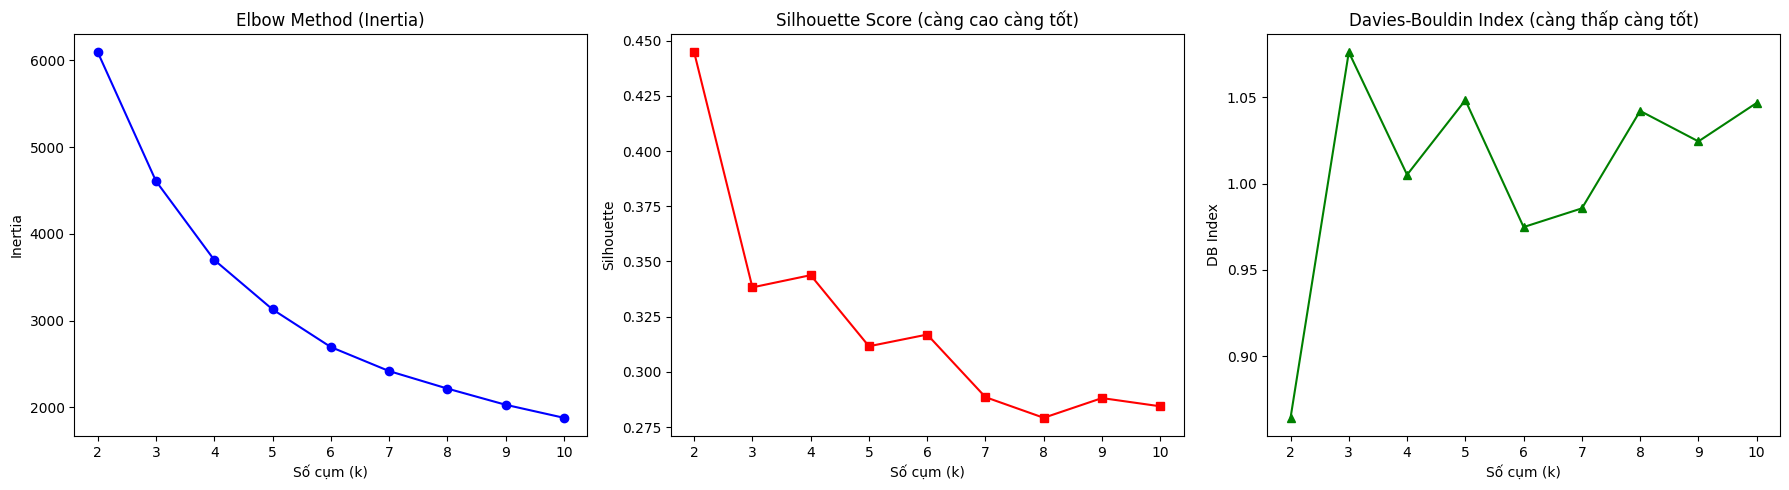

In [18]:
plt.figure(figsize=(6, 5))
plt.plot(results_df['k'], results_df['inertia'], marker='o', color='b')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig("elbow.png")
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['k'], results_df['inertia'], marker='o', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Số cụm (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(results_df['k'], results_df['silhouette'], marker='s', color='r')
axes[1].set_title('Silhouette Score (càng cao càng tốt)')
axes[1].set_xlabel('Số cụm (k)')
axes[1].set_ylabel('Silhouette')

axes[2].plot(results_df['k'], results_df['davies_bouldin'], marker='^', color='g')
axes[2].set_title('Davies-Bouldin Index (càng thấp càng tốt)')
axes[2].set_xlabel('Số cụm (k)')
axes[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()

## 2. Chọn k tối ưu

Tuy K=2 cao nhất nhưng phân cụm thành 2 là quá ít và không mang lại nhiều giá trị. Nên chọn K=4 (cái cao nhì)

In [5]:
optimal_k = 4



## 3. Huấn luyện 2 mô hình phân cụm

### 3.1 K-Means

In [ ]:
# with wandb.init(project="customer-segmentation-online-retail", name=f"model-kmeans-k{optimal_k}_new", job_type="train") as run:
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X)

kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)
# wandb.log({"final_silhouette": kmeans_sil, "final_davies_bouldin": kmeans_db})
print(f"K-Means | Silhouette: {kmeans_sil:.4f} | DB Index: {kmeans_db:.4f}")

#os.makedirs("models", exist_ok=True)
#joblib.dump(kmeans_model, f"models/kmeans_model_k{optimal_k}.pkl")
# artifact = wandb.Artifact(name=f"kmeans_model_k{optimal_k}", type="model")
# artifact.add_file(f"models/kmeans_model_k{optimal_k}.pkl")
# run.log_artifact(artifact)

K-Means | Silhouette: 0.3438 | DB Index: 1.0051


### 3.2 Hierarchical Clustering (Agglomerative)

In [12]:
import joblib
import wandb  
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Khai báo không gian tìm kiếm
k_range = range(2, 11)
linkage_options = ["ward", "complete", "average", "single"]

print("--- Bắt đầu Grid Search và Log lên W&B ---")

for linkage in linkage_options:
    for k in k_range:
        try:
            # Khởi tạo một lượt chạy mới trên W&B cho từng tổ hợp tham số
            run = wandb.init(
                project="customer-segmentation-online-retail",
                name=f"hierarchical-{linkage}-k{k}",
                config={"algorithm": "Hierarchical", "linkage": linkage, "k": k},
                job_type="tuning",
                reinit=True,  # Cho phép khởi tạo lại nhiều lần trong vòng lặp
            )

            # Huấn luyện mô hình thử nghiệm
            model_test = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels_test = model_test.fit_predict(X)

            # Tính toán chỉ số
            sil_test = silhouette_score(X, labels_test)
            db_test = davies_bouldin_score(X, labels_test)

            # Log trực tiếp các chỉ số này lên W&B
            wandb.log({"silhouette_score": sil_test, "davies_bouldin_index": db_test})

            print(
                f"Logged: Linkage={linkage} | K={k} | Sil={sil_test:.4f} | DB={db_test:.4f}"
            )

            # Kết thúc lượt chạy hiện tại
            run.finish()

        except Exception as e:
            print(f"Lỗi tại Linkage={linkage}, K={k}: {str(e)}")
            if "run" in locals() and run:
                run.finish()
            continue

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Mrs Linh\_netrc.


--- Bắt đầu Grid Search và Log lên W&B ---


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Logged: Linkage=ward | K=2 | Sil=0.3815 | DB=0.9636


davies_bouldin_index,▁
silhouette_score,▁
davies_bouldin_index,0.96357
silhouette_score,0.38147


...

davies_bouldin_index,▁
silhouette_score,▁
davies_bouldin_index,0.575
silhouette_score,0.19404


Logged: Linkage=single | K=9 | Sil=0.1826 | DB=0.5531


davies_bouldin_index,▁
silhouette_score,▁
davies_bouldin_index,0.5531
silhouette_score,0.18259


Logged: Linkage=single | K=10 | Sil=0.1824 | DB=0.5263


davies_bouldin_index,▁
silhouette_score,▁
davies_bouldin_index,0.52625
silhouette_score,0.18238


In [16]:

# Khai báo cấu hình tối ưu được chọn sau quá trình Grid Search
best_k = 3
optimal_linkage = "ward"

print(
    f"--- Huấn luyện mô hình Hierarchical tối ưu (K={best_k}, Linkage={optimal_linkage}) ---"
)

# Huấn luyện mô hình chính thức và gán nhãn cụm
hier_model = AgglomerativeClustering(
    n_clusters=best_k, linkage=optimal_linkage
)
hier_labels = hier_model.fit_predict(X)

# Tính toán các chỉ số đánh giá để truyền xuống cell so sánh ở dưới
hier_sil = silhouette_score(X, hier_labels)
hier_db = davies_bouldin_score(X, hier_labels)


print(
    f"Hoàn thành! | Silhouette: {hier_sil:.4f} | Davies-Bouldin: {hier_db:.4f}"
)





# Kết thúc lượt chạy
run.finish()

--- Huấn luyện mô hình Hierarchical tối ưu (K=3, Linkage=ward) ---
Hoàn thành! | Silhouette: 0.3080 | Davies-Bouldin: 1.0738


## 4. So sánh 2 mô hình

       Model  So cum  Silhouette  Davies-Bouldin
     K-Means       4    0.343782        1.005117
Hierarchical       3    0.307957        1.073800


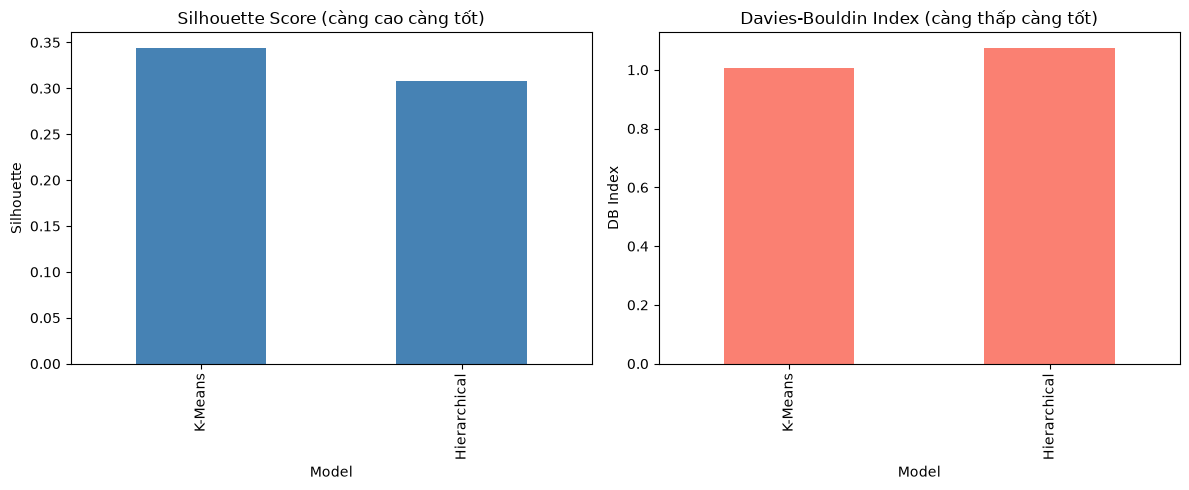

In [18]:
comparison = pd.DataFrame([
    {"Model": "K-Means", "So cum": 4, "Silhouette": kmeans_sil, "Davies-Bouldin": kmeans_db},
    {"Model": "Hierarchical", "So cum": best_k, "Silhouette": hier_sil, "Davies-Bouldin": hier_db},
])
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
comparison.plot(x='Model', y='Silhouette', kind='bar', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Silhouette Score (càng cao càng tốt)')
axes[0].set_ylabel('Silhouette')
comparison.plot(x='Model', y='Davies-Bouldin', kind='bar', ax=axes[1], legend=False, color='salmon')
axes[1].set_title('Davies-Bouldin Index (càng thấp càng tốt)')
axes[1].set_ylabel('DB Index')
plt.tight_layout()
plt.show()

## 5. Phân tích đặc điểm từng cụm (Business Profiling) — theo mô hình tốt nhất

Mô hình tốt nhất theo Silhouette: K-Means (0.3438)
            Recency  Frequency     Monetary  So luong khach
Cluster                                                    
0         18.683578   1.905207   473.624579             749
1        183.243715   1.229749   293.720259            1432
2         86.203008   3.459482  1367.583804            1197
3         13.309375   8.120833  2724.415260             960


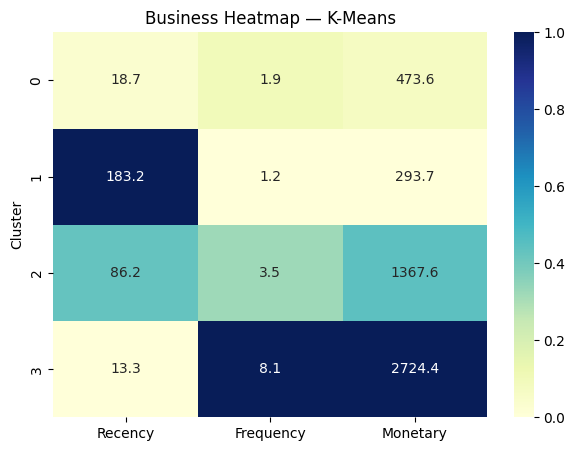

In [ ]:
candidates = {"K-Means": (kmeans_labels, kmeans_sil), "Hierarchical": (hier_labels, hier_sil)}


best_model_name = max(candidates, key=lambda m: candidates[m][1])
best_labels = candidates[best_model_name][0]
print(f"Mô hình tốt nhất theo Silhouette: {best_model_name} ({candidates[best_model_name][1]:.4f})")

rfm_raw = rfm_raw.copy()
rfm_raw['Cluster'] = best_labels

cluster_summary = rfm_raw.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_counts = rfm_raw.groupby('Cluster').size().rename('So luong khach')
cluster_summary = cluster_summary.join(cluster_counts)
print(cluster_summary)

metrics_only = cluster_summary[['Recency', 'Frequency', 'Monetary']]
cluster_summary_scaled = (metrics_only - metrics_only.min()) / (metrics_only.max() - metrics_only.min())

plt.figure(figsize=(7, 5))
sns.heatmap(cluster_summary_scaled, annot=metrics_only, fmt=".1f", cmap="YlGnBu")
plt.title(f'Business Heatmap — {best_model_name}')
plt.show()

## 6. Gán cụm K-Means cho toàn bộ khách hàng và xuất file kết quả cuối cùng


In [27]:
# Đọc lại RFM gốc (đơn vị thật, dùng để diễn giải) và gán Cluster theo K-Means
rfm_full = pd.read_csv("../data/processed/customer_segmentation.csv")
rfm_full['Cluster'] = kmeans_labels

print(f"Đã gán cụm (K-Means) cho toàn bộ {rfm_full.shape[0]:,} khách hàng.")
rfm_full.head()

Đã gán cụm (K-Means) cho toàn bộ 4,338 khách hàng.


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,3691.77,2
1,12347,1,7,3691.77,3
2,12348,74,4,1797.24,2
3,12349,18,1,1757.55,0
4,12350,309,1,334.40,1


### 6.1 Gán tên persona (nhãn kinh doanh) cho từng cụm

In [28]:
import os
import json as _json
from datetime import datetime, timedelta
from groq import Groq
from dotenv import load_dotenv

# Tự động nạp các biến môi trường từ file .env vào os.environ
load_dotenv()

# 1. Tính đặc điểm trung bình từng cụm (giữ làm ngữ cảnh cho LLM + fallback an toàn)
cluster_stats = rfm_full[rfm_full['Cluster'] != -1].groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_stats['SoLuongKhach'] = rfm_full[rfm_full['Cluster'] != -1].groupby('Cluster').size()
cluster_stats['rank_recency'] = cluster_stats['Recency'].rank(ascending=True)
cluster_stats['rank_frequency'] = cluster_stats['Frequency'].rank(ascending=False)
cluster_stats['rank_monetary'] = cluster_stats['Monetary'].rank(ascending=False)
cluster_stats['rank_score'] = cluster_stats[['rank_recency', 'rank_frequency', 'rank_monetary']].mean(axis=1)
cluster_stats = cluster_stats.sort_values('rank_score')

print("=== Đặc trưng các cụm hiện tại ===")
print(cluster_stats[['Recency', 'Frequency', 'Monetary', 'SoLuongKhach']])

# Bộ nhãn dự phòng (fallback) nếu gọi API lỗi
fallback_persona_pool = [
    "Khách hàng VIP (Champions)",
    "Khách hàng trung thành",
    "Khách hàng tiềm năng",
    "Khách hàng cần chăm sóc",
    "Khách hàng có nguy cơ rời bỏ",
    "Khách hàng không hoạt động"
]

# 2. Xây prompt mô tả đặc điểm từng cụm, yêu cầu LLM đặt tên persona bằng tiếng Việt
cluster_description = "\n".join([
    f"- Cluster {cid}: Recency trung bình = {row['Recency']:.1f} ngày, "
    f"Frequency trung bình = {row['Frequency']:.1f} đơn hàng, "
    f"Monetary trung bình = {row['Monetary']:,.0f}, "
    f"số lượng khách hàng = {int(row['SoLuongKhach'])}"
    for cid, row in cluster_stats.iterrows()
])

prompt = f"""Bạn là chuyên gia phân tích khách hàng (CRM/Marketing). Dưới đây là kết quả phân cụm khách hàng theo mô hình RFM (Recency = số ngày từ lần mua gần nhất, càng THẤP càng tốt; Frequency = số đơn hàng, càng CAO càng tốt; Monetary = tổng chi tiêu, càng CAO càng tốt):

{cluster_description}

Với MỖI cluster ở trên, hãy đặt:
1. "persona": một tên phân khúc khách hàng ngắn gọn bằng tiếng Việt (3-6 từ, ví dụ: "Khách hàng VIP", "Khách hàng có nguy cơ rời bỏ")
2. "description": mô tả ngắn 1 câu về đặc điểm hành vi và gợi ý chiến lược chăm sóc/marketing phù hợp cho nhóm đó

Chỉ trả về JSON hợp lệ theo đúng định dạng sau, không thêm giải thích hay markdown:
{{"0": {{"persona": "...", "description": "..."}}, "1": {{"persona": "...", "description": "..."}}}}
"""

# 3. Gọi Groq API
cluster_to_persona = {}
cluster_to_description = {}

try:
    api_key = os.environ.get("GROQ_API_KEY")
    if not api_key:
        raise ValueError("Không tìm thấy GROQ_API_KEY trong môi trường hoặc file .env")
        
    client = Groq(api_key=api_key)
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        response_format={"type": "json_object"}
    )
    raw_content = response.choices[0].message.content
    llm_result = _json.loads(raw_content)

    for cid in cluster_stats.index:
        key = str(cid)
        if key in llm_result and "persona" in llm_result[key]:
            cluster_to_persona[cid] = llm_result[key]["persona"]
            cluster_to_description[cid] = llm_result[key].get("description", "")
        else:
            raise KeyError(f"Thiếu kết quả cho cluster {cid}")

    print("\n[Thành công] Đã gọi Groq API để định danh persona.")

except Exception as e:
    print(f"\n[Thất bại] Gọi Groq API lỗi ({e}) -> Sử dụng bộ nhãn dự phòng (fallback theo rank_score).")
    cluster_to_persona = {
        cid: (fallback_persona_pool[i] if i < len(fallback_persona_pool) else f"Nhóm khách hàng {i+1}")
        for i, cid in enumerate(cluster_stats.index)
    }
    cluster_to_description = {cid: "Chưa có mô tả do lỗi kết nối AI." for cid in cluster_stats.index}

# 4. In bản đồ ánh xạ ra màn hình kiểm tra
print("\n=== Ánh xạ Cluster -> Persona ===")
for cid, name in cluster_to_persona.items():
    desc = cluster_to_description.get(cid, "")
    print(f"Cluster {cid} -> {name}" + (f" | {desc}" if desc else ""))

# 5. Khớp kết quả ngược lại dataframe tổng
rfm_full['Persona'] = rfm_full['Cluster'].map(cluster_to_persona)
rfm_full['Persona_Description'] = rfm_full['Cluster'].map(cluster_to_description)

# Xử lý các điểm nhiễu (mã là -1 nếu có từ DBSCAN/HDBSCAN)
rfm_full.loc[rfm_full['Cluster'] == -1, 'Persona'] = 'Không xác định (Nhiễu)'
rfm_full.loc[rfm_full['Cluster'] == -1, 'Persona_Description'] = 'Các bản ghi không thuộc bất kỳ nhóm hành vi đặc trưng nào.'

# Hiển thị kết quả mẫu
print("\n=== Dữ liệu phân cụm sau khi định danh (5 dòng đầu) ===")
print(rfm_full.head())

=== Đặc trưng các cụm hiện tại ===
            Recency  Frequency     Monetary  SoLuongKhach
Cluster                                                  
3         13.309375   8.120833  2724.415260           960
2         86.203008   3.459482  1367.583804          1197
0         18.683578   1.905207   473.624579           749
1        183.243715   1.229749   293.720259          1432

[Thất bại] Gọi Groq API lỗi (Không tìm thấy GROQ_API_KEY trong môi trường hoặc file .env) -> Sử dụng bộ nhãn dự phòng (fallback theo rank_score).

=== Ánh xạ Cluster -> Persona ===
Cluster 3 -> Khách hàng VIP (Champions) | Chưa có mô tả do lỗi kết nối AI.
Cluster 2 -> Khách hàng trung thành | Chưa có mô tả do lỗi kết nối AI.
Cluster 0 -> Khách hàng tiềm năng | Chưa có mô tả do lỗi kết nối AI.
Cluster 1 -> Khách hàng cần chăm sóc | Chưa có mô tả do lỗi kết nối AI.

=== Dữ liệu phân cụm sau khi định danh (5 dòng đầu) ===
   CustomerID  Recency  Frequency  Monetary  Cluster  \
0       12346      325          1  

### 6.2 Xuất file kết quả phân cụm cuối cùng

In [29]:
final_output_path = "../data/processed/customer_segments_final.csv"
rfm_full.to_csv(final_output_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu file kết quả phân cụm cuối cùng tại: {final_output_path}")
print(f"Các cột: {list(rfm_full.columns)}")

print("\nSố lượng khách hàng theo Persona:")
print(rfm_full['Persona'].value_counts())

Đã lưu file kết quả phân cụm cuối cùng tại: ../data/processed/customer_segments_final.csv
Các cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Persona', 'Persona_Description']

Số lượng khách hàng theo Persona:
Persona
Khách hàng cần chăm sóc       1432
Khách hàng trung thành        1197
Khách hàng VIP (Champions)     960
Khách hàng tiềm năng           749
Name: count, dtype: int64


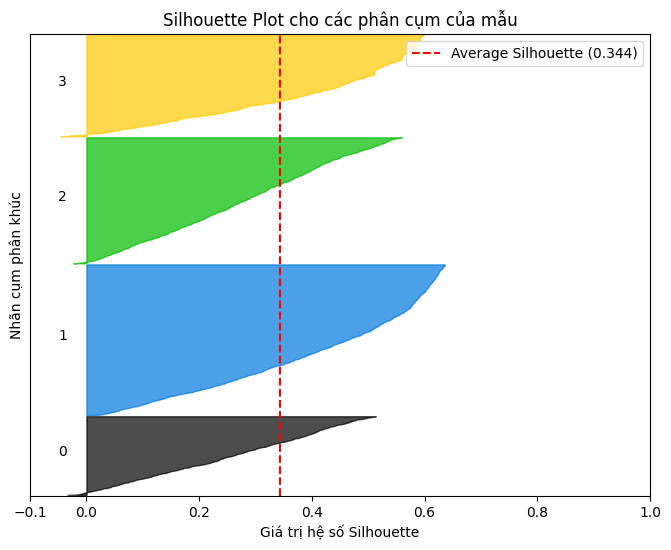

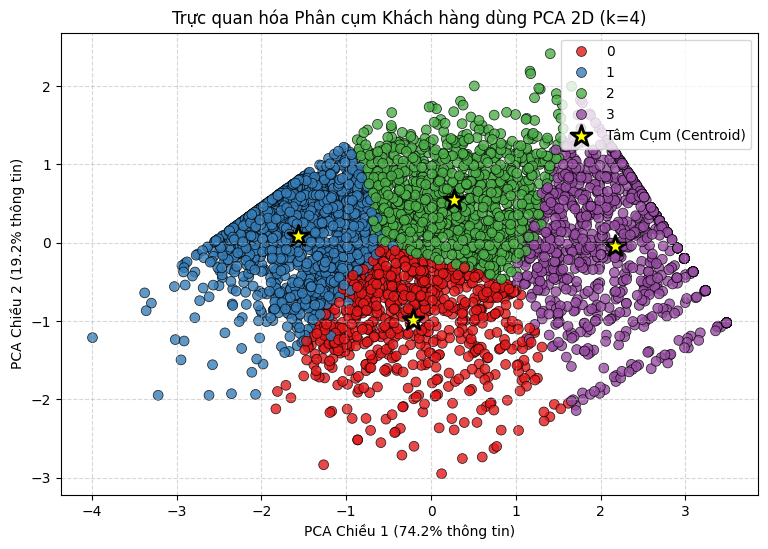

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

# =========================================================================
# 1. VẼ BIỂU ĐỒ SILHOUETTE ANALYSIS (CHI TIẾT TỪNG CỤM)
# =========================================================================
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Giới hạn trục X từ -0.1 đến 1
ax1.set_xlim([-0.1, 1])
# Trục Y cần khoảng trống giữa các cụm
ax1.set_ylim([0, len(X) + (optimal_k + 1) * 10])

# Tính toán điểm silhouette cho từng mẫu dữ liệu
sample_silhouette_values = silhouette_samples(X, kmeans_labels)
cluster_labels = kmeans_labels
sil_score = silhouette_score(X, kmeans_labels)

y_lower = 10
for i in range(optimal_k):
    # Gom cụm các giá trị mẫu thuộc cụm i và sắp xếp chúng
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Dán nhãn số thứ tự cụm vào giữa các thanh đồ thị
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Tính toán vị trí đáy cho cụm tiếp theo
    y_lower = y_upper + 10  # 10 cho khoảng trống giữa các cụm

ax1.set_title("Silhouette Plot cho các phân cụm của mẫu")
ax1.set_xlabel("Giá trị hệ số Silhouette")
ax1.set_ylabel("Nhãn cụm phân khúc")

# Đường kẻ đứt nét biểu diễn giá trị Silhouette trung bình tổng thể
ax1.axvline(x=sil_score, color="red", linestyle="--", label=f"Average Silhouette ({sil_score:.3f})")
ax1.set_yticks([])  # Xóa các vạch số của trục Y
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.legend(loc="upper right")

plt.savefig(f"silhouette_analysis_k{optimal_k}.png")
plt.show()


# =========================================================================
# 2. TRỰC QUAN HÓA CỤM TRÊN KHÔNG GIAN HAI CHIỀU DÙNG PCA
# =========================================================================
# Vì dữ liệu RFM có 3 chiều (Recency, Frequency, Monetary), ta dùng PCA đưa về 2 chiều để vẽ đồ thị phẳng
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Tạo dataframe để vẽ seaborn dễ dàng
pca_df = pd.DataFrame(data=X_pca, columns=['PCA Chiều 1', 'PCA Chiều 2'])
pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(9, 6))
# Trực quan hóa sự phân tách giữa các cụm khách hàng
sns.scatterplot(
    x='PCA Chiều 1', y='PCA Chiều 2',
    hue='Cluster',
    palette=sns.color_palette('Set1', n_colors=optimal_k),
    data=pca_df,
    legend="full",
    alpha=0.8,
    edgecolor='k',
    s=50
)

# Lấy tọa độ các tâm cụm (centroids) và chiếu lên không gian PCA
centers_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='yellow', 
    s=250, 
    marker='*', 
    edgecolors='black', 
    linewidths=2,
    label='Tâm Cụm (Centroid)'
)

plt.title(f'Trực quan hóa Phân cụm Khách hàng dùng PCA 2D (k={optimal_k})')
plt.xlabel(f'PCA Chiều 1 ({pca.explained_variance_ratio_[0]*100:.1f}% thông tin)')
plt.ylabel(f'PCA Chiều 2 ({pca.explained_variance_ratio_[1]*100:.1f}% thông tin)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"kmeans_pca_scatter_k{optimal_k}.png")
plt.show()